# Californa housing

## Setup & Data Loading

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.dummy import DummyRegressor

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv("data/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Dataset Overview

In [3]:
print("Dataset shape:", df.shape)
print("---------------------------")
print("Columns:", df.columns)
print("---------------------------")

Dataset shape: (20640, 10)
---------------------------
Columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')
---------------------------


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


#### Dataset summary
- The dataset includes 20,640 observations and 10 variables. 
- All numerical variables is of the type float64. 
- There is one categorical value: *ocean_proximity*.
- Target-varibale is *median_house_value*.

### Missing Values

In [9]:
print("Missning values per column:")
print(df.isna().sum())

Missning values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [8]:
print("Missning values per column (%):")
df.isnull().sum() / len(df) * 100

Missning values per column (%):


longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

There are 207, about 1 %, missing values in *total_bedrooms*. Missing values will be managed with SimpleImputer, median imputation, in scikit-learn as a step in the pipeline. This method will be used as it:
- avoids leakage, imputation will only be learned from training data
- works inside the pipeline, and automatically applied to test data
- keeps preprocessing consistent

### Preparing classification problem

Create a binary target *high_value*:
- high_value = 1 if median_house_value is in the top 20%
- high_value = 0 otherwise

In [11]:
# 1. Compute the threshold
threshold = df["median_house_value"].quantile(0.8)
print("80th percentile threshold:", threshold)

# 2. Create the binary target
df["high_value"] = (
    df["median_house_value"] >= threshold
).astype(int)

# 3. Checking class balance
df["high_value"].value_counts(normalize=True)

# 4. Define X and y
X_full = df.drop(["median_house_value", "high_value"], axis=1)                  
y_full = df["high_value"]

print("X:", X_full.shape, "y:", y_full.shape)

80th percentile threshold: 290000.0
X: (20640, 9) y: (20640,)


## EDA

### Class distribution of target

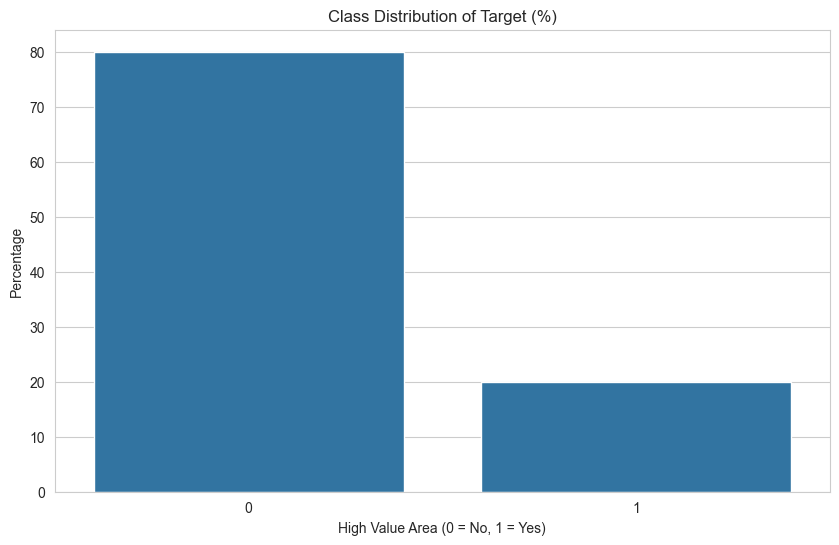

In [12]:
class_dist = y_full.value_counts(normalize=True) * 100

sns.barplot(
    x=class_dist.index,
    y=class_dist.values
)
plt.ylabel("Percentage")
plt.xlabel("High Value Area (0 = No, 1 = Yes)")
plt.title("Class Distribution of Target (%)")
plt.show()

#### Summary of Class Distribution
The class distribution of target show an imbalance in the data. Only 20 % of the historical observations are classified as high-value areas. 

### Correlation with target (high-value area)

Correlations show how strongly numerical features separates high-value areas from non-high-value areas. Categorial features is excluded since correlation measures the linear relationship between numerical features. 

In [13]:
train_with_target = X_full.copy()
train_with_target["median_house_value"] = y_full

corr_with_target = (
    train_with_target
    .drop("ocean_proximity", axis=1)
    .corr()["median_house_value"]
    .sort_values(ascending=False)
)

print(corr_with_target)

median_house_value    1.000000
median_income         0.539601
housing_median_age    0.102797
total_rooms           0.090348
households            0.021009
total_bedrooms        0.012439
latitude             -0.054018
population           -0.056901
longitude            -0.066693
Name: median_house_value, dtype: float64


### Highest correlating feature vs high-value area

Highest correlating features is *median_income*.

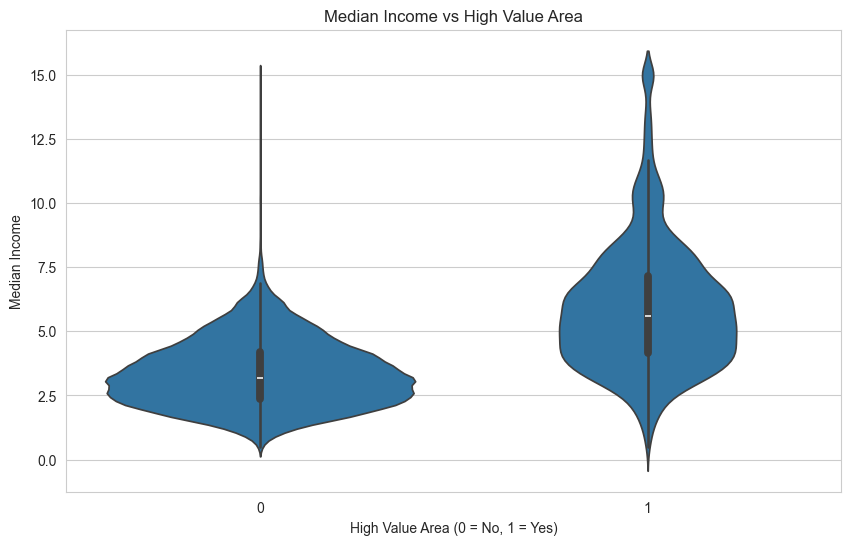

In [14]:
sns.violinplot(
    x=y_full, 
    y=X_full["median_income"] 
   )
plt.xlabel("High Value Area (0 = No, 1 = Yes)")
plt.ylabel("Median Income")
plt.title("Median Income vs High Value Area")
plt.show()

The high-value areas have a clearly higher median income compared to the other group. The medians of the two groups are well separated, indicating a noticeable difference in income levels between them. Additionally, there are high-income outliers present in both groups. Overall, this suggests that median_income appears to be a strong predictor of *high_value*.

### Geographical distribution of high-value areas
Geographical distribution of high-value areas show where high-value areas located geographically. 

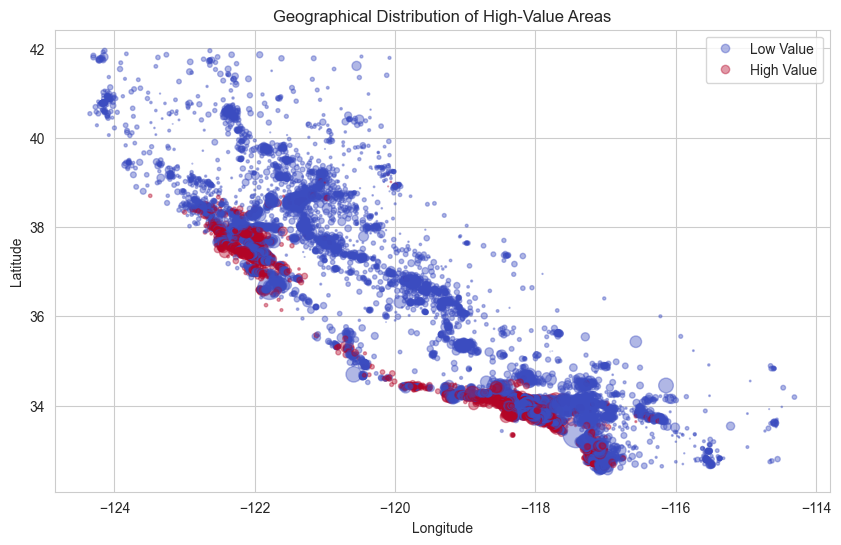

In [15]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_full["longitude"],
    X_full["latitude"],
    s=X_full["population"]/100,
    c=y_full,
    cmap="coolwarm",
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of High-Value Areas")

plt.legend(handles=scatter.legend_elements()[0],
           labels=["Low Value", "High Value"])

plt.show()

High-value areas are primarily concentrated along the coastline and around urban centers. In contrast, lower-value areas are more common inland. This pattern suggests that geographical location has a strong influence on variations in housing prices.

### Ocean Proximity
Plotting ocean proximity show how distance to the ocean affect probability of being a high-value property. 

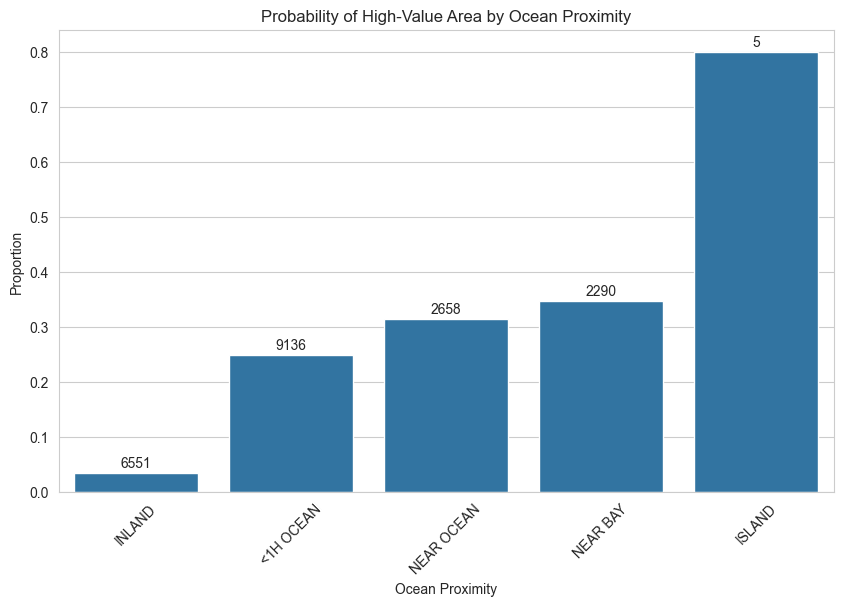

In [17]:
train_with_target = X_full.copy()
train_with_target["high_value"] = y_full

ocean_high_value_rate = (
    train_with_target
    .groupby("ocean_proximity")["high_value"]
    .mean()
    .sort_values()
)

counts = train_with_target["ocean_proximity"].value_counts()

ax = sns.barplot(
    x=ocean_high_value_rate.index,
    y=ocean_high_value_rate.values
)

plt.ylabel("Proportion")
plt.xlabel("Ocean Proximity")
plt.xticks(rotation=45)
plt.title("Probability of High-Value Area by Ocean Proximity")

for i, category in enumerate(ocean_high_value_rate.index):
    count = counts[category]
    proportion = ocean_high_value_rate[category]
    
    ax.text(
        i,                      
        proportion + 0.01,      
        count,           
        ha="center"
    )

plt.show()

Inland areas have a high-value rate of about 5%. Areas located less than one hour from the ocean show a substantially higher rate of around 25%. Locations near the ocean have a slightly higher proportion, at roughly 30%, and areas near the bay also show a rate slightly above 30%. In contrast, island areas have the highest share of high-value observations, with about 80%. Overall, this indicates a strong location effect, although island observations are much rarer than the other categories.

## Split & preprocessing

- Dela datan i train och test.
- Klassificering: använd stratifierad split (stratify) så att klasserna fördelas rimligt i train/test.
- manage missing values on training data - fit imputer and apply on training data

### Train/test-split

The datset is divided into train and test sets with a 80/20 distribution. **stratify=y_full** guarantees that the proportions of "high-value" are distributed equally across test and train sets. 

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("Train shape: \n "
    "x:", X_train.shape,
    "y:", y_train.shape)
print("Test shape: \n "
    "x:", X_test.shape,
    "y:", y_test.shape)
print("-------------------------------")
print(f"Classification train: \n{y_train.value_counts(normalize=True)}")
print("-------------------------------")
print(f"Classification test: \n{y_test.value_counts(normalize=True)}")
print("-------------------------------")

Train shape: 
 x: (16512, 9) y: (16512,)
Test shape: 
 x: (4128, 9) y: (4128,)
-------------------------------
Classification train: 
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64
-------------------------------
Classification test: 
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64
-------------------------------


### Feature engineering

total_rooms, population, households brukar ibland fungera bättre om man skapar features som:

rooms_per_household

bedrooms_per_room

population_per_household

Men det är extra feature engineering, inte nödvändigt.

### Feature selection

Numerical and categorial values are seperated since they require different steps in preprocessing.

*median_house_value* is excluded from numerical features as target (*high_value*) is created from it and to avoid data leakage. 

In [4]:
num_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

cat_features = [
    "ocean_proximity"
]

### Creating pipelines

In [9]:
# 1. Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 2. Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# 3. Combinding pipelines with ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
    ],
    remainder="drop"
)

# 4. Creating full pipeline with LogisticRegression
full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression())
])

## Unsupervised learning (PCA or KMeans)

Ledningen vill inte bara ha en modell – de vill också förstå om det finns naturliga grupper av områden i datan. Om sådana grupper finns kan det hjälpa till att:
segmentera områden (t.ex. “typområden” som liknar varandra),
upptäcka ovanliga områden (avvikare),
och få en enklare överblick över datan innan man tar beslut.

Uppdrag: 
Du ska därför undersöka om datan verkar innehålla struktur genom att använda PCA eller KMeans på ett rimligt urval av X-variabler (inte target).

Syfte - Att se om vi kan:
- sammanfatta datan i ett enklare “mönster” (PCA), eller
- hitta grupper av liknande områden (KMeans),
- och diskutera hur detta skulle kunna användas som beslutsstöd.

Krav:
- Implementera PCA eller KMeans
- Visa resultat (figur/tabell)
- Tolka kort: vad kan vi lära oss, och vad är osäkert?

Använd endast X-variabler (inte target), och motivera kort vilka features du inkluderade. Kom ihåg att metoderna är känsliga för skalning.

## Modelling

- Skapa en baseline.
- Träna minst två ytterligare modeller (totalt minst 3 inkl baseline).
- Jämför modellerna med en tydlig utvärderingsmetod (t.ex. cross-validation eller valideringsupplägg).

## Model optimization

- Välj en modell baserat på din jämförelse.
- Optimera den valda modellen med hyperparameter-tuning (t.ex. GridSearchCV). Du väljer själv vilka parametrar som är relevanta
- Beskriv kort vad du optimerade och vilken metric du optimerade mot.


## Evaluation on test result + recommendations

- Utvärdera din slutliga modell på testdata och rapportera resultatet.
- Välj minst en relevant metric och motivera valet:
- Regression: t.ex. MAE eller RMSE
- Klassificering: t.ex. F1 eller recall/precision
- Sammanfatta resultat tydligt (tabell rekommenderas).
- Skriv en kort rekommendation: vilken modell skulle du ta vidare och varför?